In [ ]:
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import torch
import random
import torch.nn as nn
import sklearn
import collections
from sklearn.model_selection import train_test_split
import json
from torch.optim import Adam
import pylab
from scipy.optimize import curve_fit
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
import sys
sys.path.insert(0,'/content/gdrive/MyDrive/Penn/Colab/Data/')
from functions import load_model, save_model, Dataset, mse_loss
from sklearn.metrics import roc_curve, auc
import xgboost as xgb
from torch.utils.data import Dataset, DataLoader

Mounted at /content/gdrive


In [ ]:
def load_subdicts_from_h5(save_dir, tags_to_use=None):
    """
    Loads sub-dictionaries of NumPy arrays from HDF5 files in a directory and reconstructs the original structure.

    Args:
        save_dir (str): The directory where the HDF5 files are stored.

    Returns:
        main_dict (dict): A dictionary of dictionaries where the innermost values are NumPy arrays.
    """
    main_dict = {}

    for filename in os.listdir(save_dir):
        if filename.endswith(".h5") and not filename.startswith('.'):

            sub_dict_name = os.path.splitext(filename)[0]
            if tags_to_use is not None and sub_dict_name not in tags_to_use:
                continue
            file_path = os.path.join(save_dir, filename)
            with h5py.File(file_path, 'r') as f:
                sub_dict = {key: np.array(f[key]) for key in f}
            main_dict[sub_dict_name] = sub_dict
            print(f"Loaded {sub_dict_name} from {file_path}")

    return main_dict

In [ ]:
#datasets = load_subdicts_from_h5('/content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/datasets2')
datasets = load_subdicts_from_h5('/content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets')

Loaded Background from /content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets/Background.h5
Loaded Ato4l from /content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets/Ato4l.h5
Loaded hChToTauNu from /content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets/hChToTauNu.h5
Loaded hToTauTau from /content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets/hToTauTau.h5
Loaded leptoquark from /content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets/leptoquark.h5
Loaded val from /content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets/val.h5
Loaded train from /content/gdrive/MyDrive/Penn/Colab/AD/chop_or_not/saved_datasets/train.h5


In [ ]:
for tag, data_dict in datasets.items():
    print(f"Tag: {tag}")
    for key, value in data_dict.items():
        print(f"  {key}: {value.shape}")

Tag: Background
  KL_AD_scores: (200000,)
  MSE_AD_scores: (200000,)
  clipped_KL_AD_scores: (200000,)
  data: (200000, 57)
  large_student_AD_scores: (200000,)
  medium_student_AD_scores: (200000,)
  small_student_AD_scores: (200000,)
Tag: Ato4l
  KL_AD_scores: (55969,)
  MSE_AD_scores: (55969,)
  clipped_KL_AD_scores: (55969,)
  data: (55969, 57)
  large_student_AD_scores: (55969,)
  medium_student_AD_scores: (55969,)
  small_student_AD_scores: (55969,)
Tag: hChToTauNu
  KL_AD_scores: (760272,)
  MSE_AD_scores: (760272,)
  clipped_KL_AD_scores: (760272,)
  data: (760272, 57)
  large_student_AD_scores: (760272,)
  medium_student_AD_scores: (760272,)
  small_student_AD_scores: (760272,)
Tag: hToTauTau
  KL_AD_scores: (691283,)
  MSE_AD_scores: (691283,)
  clipped_KL_AD_scores: (691283,)
  data: (691283, 57)
  large_student_AD_scores: (691283,)
  medium_student_AD_scores: (691283,)
  small_student_AD_scores: (691283,)
Tag: leptoquark
  KL_AD_scores: (340544,)
  MSE_AD_scores: (340544,)


In [ ]:
def plot_roc_curves(datasets, AD_score_type='MSE_AD_scores'):
    plt.figure(figsize=(8, 5))

    bkg_scores = datasets['Background'][AD_score_type]
    bkg_labels = np.zeros_like(bkg_scores)

    skip_tags = ['Background', 'train', 'val']

    for tag, data_dict in datasets.items():
        if tag in skip_tags: continue

        sig_scores = data_dict[AD_score_type]
        combined_scores = np.concatenate([bkg_scores, sig_scores])
        combined_labels = np.concatenate([bkg_labels, np.ones_like(sig_scores)])

        fpr, tpr, thresholds = roc_curve(y_true=combined_labels, y_score=combined_scores)
        roc_auc = auc(fpr, tpr)

        threshold_idx = np.argmin(np.abs(fpr - 1e-5))
        threshold_tpr = tpr[threshold_idx]


        plt.plot(fpr, tpr, label=f'{tag} (AUC = {roc_auc:.2f}, $\epsilon$ = {threshold_tpr:.2e})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.axvline(x=1e-5, color='red', linestyle='--')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves: {AD_score_type}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

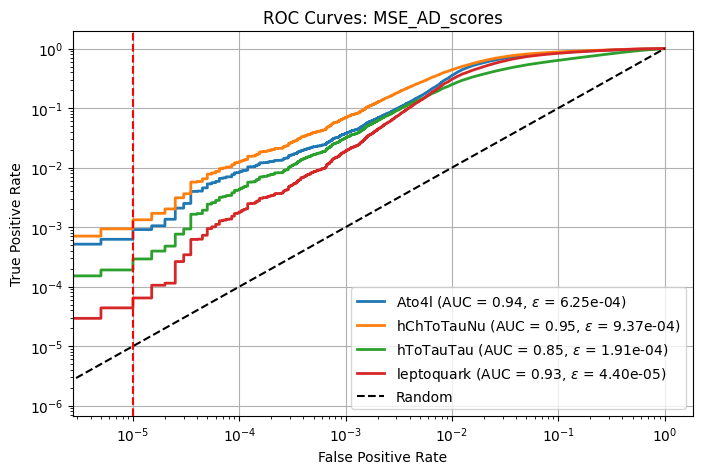

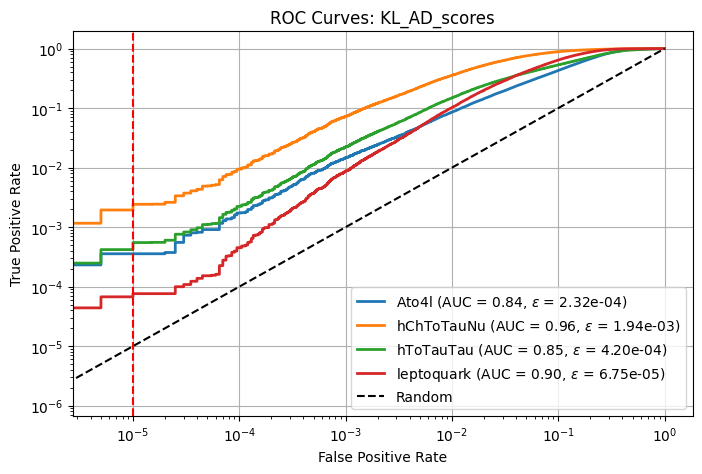

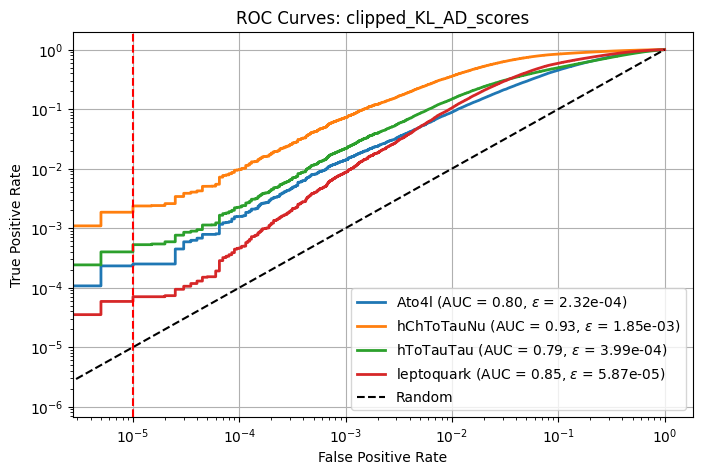

In [ ]:
plot_roc_curves(datasets, AD_score_type='MSE_AD_scores')
plot_roc_curves(datasets, AD_score_type='KL_AD_scores')
plot_roc_curves(datasets, AD_score_type='clipped_KL_AD_scores')

In [ ]:
class StudentNetSmall(nn.Module):
    def __init__(self, input_dim=57):
        super(StudentNetSmall, self).__init__()
        # Just one Linear layer: [input_dim] → [1]
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        out = self.fc(x)  # → (batch_size, 1)
        return out


# -- Medium network: one hidden layer --
class StudentNetMedium(nn.Module):
    def __init__(self, input_dim=57, hidden_dim=64):
        super(StudentNetMedium, self).__init__()
        # Linear → ReLU → Linear
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        h = self.act(self.fc1(x))  # → (batch_size, hidden_dim)
        out = self.fc2(h)          # → (batch_size, 1)
        return out


# -- Large network: two hidden layers --
class StudentNetLarge(nn.Module):
    def __init__(self, input_dim=57, hidden1=128, hidden2=64):
        super(StudentNetLarge, self).__init__()
        # Linear → ReLU → Linear → ReLU → Linear
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.act1 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.act2 = nn.ReLU(inplace=True)
        self.fc3 = nn.Linear(hidden2, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        h1 = self.act1(self.fc1(x))  # → (batch_size, hidden1)
        h2 = self.act2(self.fc2(h1)) # → (batch_size, hidden2)
        out = self.fc3(h2)           # → (batch_size, 1)
        return out

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from typing import Optional, Dict, Any
import os


class Trainer:
    """
    Trainer class for regression models (e.g., StudentNetSmall/Medium/Large) in PyTorch.
    Handles training, validation, checkpointing, and learning‐rate scheduling.
    """

    def __init__(
        self,
        model: nn.Module,
        train_loader: torch.utils.data.DataLoader,
        val_loader: torch.utils.data.DataLoader,
        device: Optional[torch.device] = None,
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        scheduler_params: Optional[Dict[str, Any]] = None,
        checkpoint_dir: str = "./checkpoints",
    ):
        """
        Args:
            model:             The PyTorch model to train.
            train_loader:      DataLoader for the training set. Batches should yield (features, targets).
            val_loader:        DataLoader for the validation set. Batches should yield (features, targets).
            device:            torch.device (e.g., torch.device("cuda") or torch.device("cpu")).
                               If None, defaults to "cuda" if available, else "cpu".
            lr:                Initial learning rate for Adam.
            weight_decay:      Weight‐decay (L2 penalty) for Adam.
            scheduler_params:  Dict of parameters for ReduceLROnPlateau scheduler.
                               Keys may include "mode", "factor", "patience", "min_lr", etc.
                               If None, defaults to {"mode": "min", "factor": 0.5, "patience": 5, "min_lr": 1e-6}.
            checkpoint_dir:    Directory where best‐model checkpoints and logs will be saved.
        """
        # Device setup
        if device is None:
            self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader

        # Loss function
        self.criterion = nn.MSELoss()

        # Optimizer
        self.optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)

        # LR Scheduler (ReduceLROnPlateau)
        default_sched = {"mode": "min", "factor": 0.5, "patience": 5, "min_lr": 1e-6, "verbose": True}
        sched_params = scheduler_params or default_sched
        self.scheduler = ReduceLROnPlateau(self.optimizer, **sched_params)

        # Checkpoint directory
        os.makedirs(checkpoint_dir, exist_ok=True)
        self.checkpoint_dir = checkpoint_dir

        # Internal bookkeeping
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "lr": [],
        }
        self.best_val_loss = float("inf")
        self.best_epoch = -1

    def train_epoch(self) -> float:
        """
        Runs one full training epoch.
        Returns:
            Average training loss over all batches in this epoch.
        """
        self.model.train()
        running_loss = 0.0
        total_samples = 0

        for batch in self.train_loader:
            # Assume batch is (features, targets)
            x_batch, y_batch = batch
            x_batch = x_batch.to(self.device, dtype=torch.float32)
            y_batch = y_batch.to(self.device, dtype=torch.float32).view(-1, 1)

            # Zero gradients
            self.optimizer.zero_grad()

            # Forward pass
            preds = self.model(x_batch)
            loss = self.criterion(preds, y_batch)

            # Backward + optimize
            loss.backward()
            self.optimizer.step()

            # Accumulate
            batch_size = x_batch.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

        avg_loss = running_loss / total_samples
        return avg_loss

    def validate(self) -> float:
        """
        Runs one full validation pass (no gradient computation).
        Returns:
            Average validation loss over all batches in the validation set.
        """
        self.model.eval()
        running_loss = 0.0
        total_samples = 0

        with torch.no_grad():
            for batch in self.val_loader:
                x_batch, y_batch = batch
                x_batch = x_batch.to(self.device, dtype=torch.float32)
                y_batch = y_batch.to(self.device, dtype=torch.float32).view(-1, 1)

                preds = self.model(x_batch)
                loss = self.criterion(preds, y_batch)

                batch_size = x_batch.size(0)
                running_loss += loss.item() * batch_size
                total_samples += batch_size

        avg_loss = running_loss / total_samples
        return avg_loss

    def fit(self, num_epochs: int, print_every: int = 1):
        """
        Full training loop over `num_epochs` epochs, performing training, validation,
        LR scheduling, and checkpointing.

        Args:
            num_epochs: Number of epochs to train.
            print_every: Print progress every `print_every` epochs.
        """
        for epoch in range(1, num_epochs + 1):
            # ---- TRAIN ----
            train_loss = self.train_epoch()

            # ---- VALIDATE ----
            val_loss = self.validate()

            # ---- LR SCHEDULER STEP ----
            # For ReduceLROnPlateau, step with validation loss:
            self.scheduler.step(val_loss)

            # ---- LOGGING ----
            current_lr = self.optimizer.param_groups[0]["lr"]
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["lr"].append(current_lr)

            if epoch % print_every == 0:
                print(
                    f"Epoch {epoch:3d} | "
                    f"Train Loss: {train_loss:.6f} | "
                    f"Val Loss: {val_loss:.6f} | "
                    f"LR: {current_lr:.2e}"
                )

        print(f"\nTraining complete. Best val_loss={self.best_val_loss:.6f} at epoch {self.best_epoch}.")



In [ ]:
class ADRegressionDataset(Dataset):
    """
    A PyTorch Dataset that takes two NumPy arrays:
      - features: shape (N, 57)
      - targets:  shape (N,)
    and returns (feature_tensor, target_tensor) per __getitem__.
    """
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        assert features.shape[0] == targets.shape[0], "Number of rows must match"
        self.features = features.astype(np.float32)
        self.targets = targets.astype(np.float32)

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]          # shape (57,)
        y = self.targets[idx]           # scalar
        return torch.from_numpy(x), torch.tensor(y).view(-1, 1)

In [ ]:
train_dataset = ADRegressionDataset(datasets['train']['data'], datasets['train']['KL_AD_scores'])
val_dataset   = ADRegressionDataset(datasets['val']['data'], datasets['val']['KL_AD_scores'])

batch_size = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,       # adjust as needed
    pin_memory=True       # if you’re on GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# 1) Prepare a list of (model_name, ModelClass, init_kwargs)
model_constructors = [
    (
        "small",
        StudentNetSmall,
        {"input_dim": datasets["Background"]["data"].shape[-1]},
    ),
    (
        "medium",
        StudentNetMedium,
        {"input_dim": datasets["Background"]["data"].shape[-1], "hidden_dim": 32},
    ),
    (
        "large",
        StudentNetLarge,
        {"input_dim": datasets["Background"]["data"].shape[-1], "hidden1": 64, "hidden2": 32},
    ),
]

# 2) Choose device
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# 3) Common scheduler settings (reuse across all three trainers)
common_scheduler_params = {
    "mode": "min",
    "factor": 0.5,
    "patience": 3,
    "min_lr": 1e-6,
    "verbose": True,
}

# 4) Loop over each (name, class, kwargs), train, then run inference on the 4 signal tags
for model_name, ModelClass, init_kwargs in model_constructors:
    print(f"\n=== TRAINING {model_name.upper()} MODEL ===")

    # Instantiate and move model to device
    model = ModelClass(**init_kwargs).to(device)

    # Create a Trainer for this model
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=1e-3,
        weight_decay=1e-5,
        scheduler_params=common_scheduler_params,
        checkpoint_dir=f"./checkpoints_{model_name}",
    )

    # Train for 50 epochs
    trainer.fit(num_epochs=50, print_every=1)

    # After training, put model in eval() mode
    model.eval()

    # 5) INFERENCE on the 4 SIGNAL DATASETS (exclude 'train and val')
    skip_tags = ['train', 'val']
    with torch.no_grad():
        for tag, subdict in datasets.items():
            if tag in skip_tags:
                continue

            # 5a) Grab the NumPy features array
            features_np = subdict["data"]  # shape (N_tag, 57)

            # 5b) Convert to torch.Tensor and send to device
            x_tensor = torch.from_numpy(features_np.astype(np.float32)).to(device)

            # 5c) Forward pass in batches (optional) or all at once
            #      If GPU memory is sufficient, you can do it all in one go:
            preds_tensor = model(x_tensor)  # shape: [N_tag, 1]

            # 5d) Move back to CPU and convert to 1D NumPy array
            preds_np = preds_tensor.cpu().numpy().squeeze()  # shape: (N_tag,)

            # 5e) Store these predictions in the same sub‐dict under a new key
            key_name = f"{model_name}_student_AD_scores"
            datasets[tag][key_name] = preds_np

            print(f"  → Inferred {key_name} for '{tag}' (N = {features_np.shape[0]})")

print("\nAll models trained and inference stored in `datasets`.")



Using device: cuda

=== TRAINING SMALL MODEL ===


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch   1 | Train Loss: 8.218764 | Val Loss: 5.325925 | LR: 1.00e-03
Epoch   2 | Train Loss: 7.509081 | Val Loss: 5.190807 | LR: 1.00e-03
Epoch   3 | Train Loss: 7.444453 | Val Loss: 5.095254 | LR: 1.00e-03
Epoch   4 | Train Loss: 7.408858 | Val Loss: 5.685680 | LR: 1.00e-03
Epoch   5 | Train Loss: 7.387658 | Val Loss: 5.093853 | LR: 1.00e-03
Epoch   6 | Train Loss: 7.401242 | Val Loss: 5.059895 | LR: 1.00e-03
Epoch   7 | Train Loss: 7.275636 | Val Loss: 5.094542 | LR: 1.00e-03
Epoch   8 | Train Loss: 7.377241 | Val Loss: 5.170097 | LR: 1.00e-03
Epoch   9 | Train Loss: 7.322778 | Val Loss: 5.001868 | LR: 1.00e-03
Epoch  10 | Train Loss: 7.386580 | Val Loss: 5.030390 | LR: 1.00e-03
Epoch  11 | Train Loss: 7.395379 | Val Loss: 5.083924 | LR: 1.00e-03
Epoch  12 | Train Loss: 7.382705 | Val Loss: 5.229805 | LR: 1.00e-03
Epoch  13 | Train Loss: 7.340534 | Val Loss: 5.211084 | LR: 5.00e-04
Epoch  14 | Train Loss: 7.244171 | Val Loss: 5.311657 | LR: 5.00e-04
Epoch  15 | Train Loss: 7.289077 |

In [ ]:
for tag, data_dict in datasets.items():
    print(f"Tag: {tag}")
    for key, value in data_dict.items():
        print(f"  {key}: {value.shape}")

Tag: Ato4l
  KL_AD_scores: (55969,)
  MSE_AD_scores: (55969,)
  clipped_KL_AD_scores: (55969,)
  data: (55969, 57)
  small_student_AD_scores: (55969,)
  medium_student_AD_scores: (55969,)
  large_student_AD_scores: (55969,)
Tag: Background
  KL_AD_scores: (200000,)
  MSE_AD_scores: (200000,)
  clipped_KL_AD_scores: (200000,)
  data: (200000, 57)
  small_student_AD_scores: (200000,)
  medium_student_AD_scores: (200000,)
  large_student_AD_scores: (200000,)
Tag: hChToTauNu
  KL_AD_scores: (760272,)
  MSE_AD_scores: (760272,)
  clipped_KL_AD_scores: (760272,)
  data: (760272, 57)
  small_student_AD_scores: (760272,)
  medium_student_AD_scores: (760272,)
  large_student_AD_scores: (760272,)
Tag: hToTauTau
  KL_AD_scores: (691283,)
  MSE_AD_scores: (691283,)
  clipped_KL_AD_scores: (691283,)
  data: (691283, 57)
  small_student_AD_scores: (691283,)
  medium_student_AD_scores: (691283,)
  large_student_AD_scores: (691283,)
Tag: leptoquark
  KL_AD_scores: (340544,)
  MSE_AD_scores: (340544,)


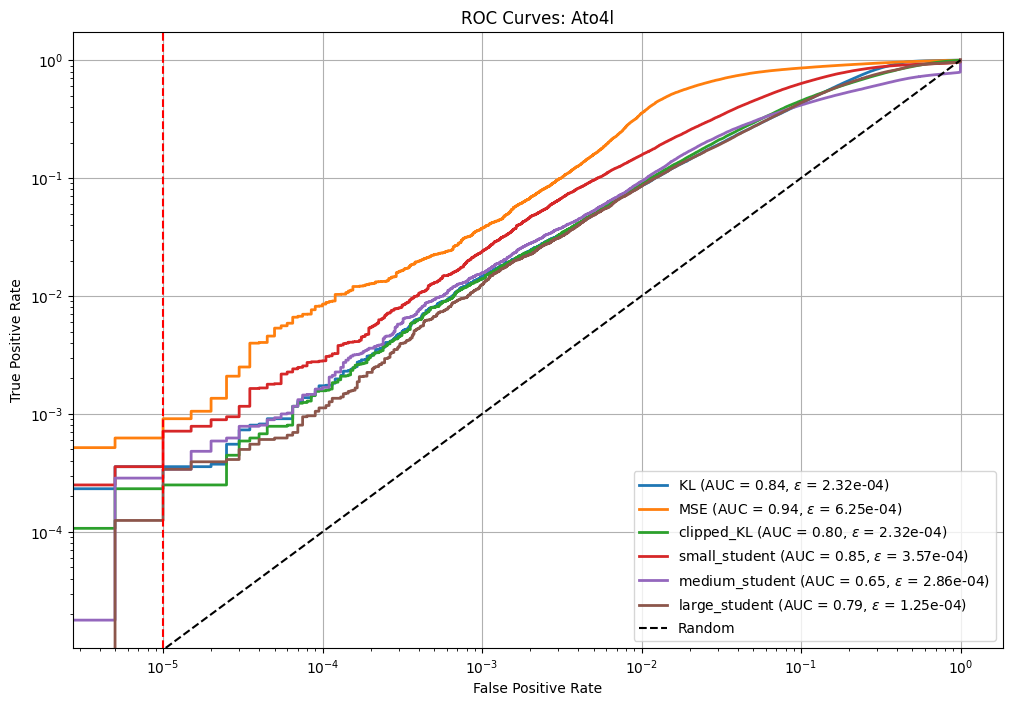

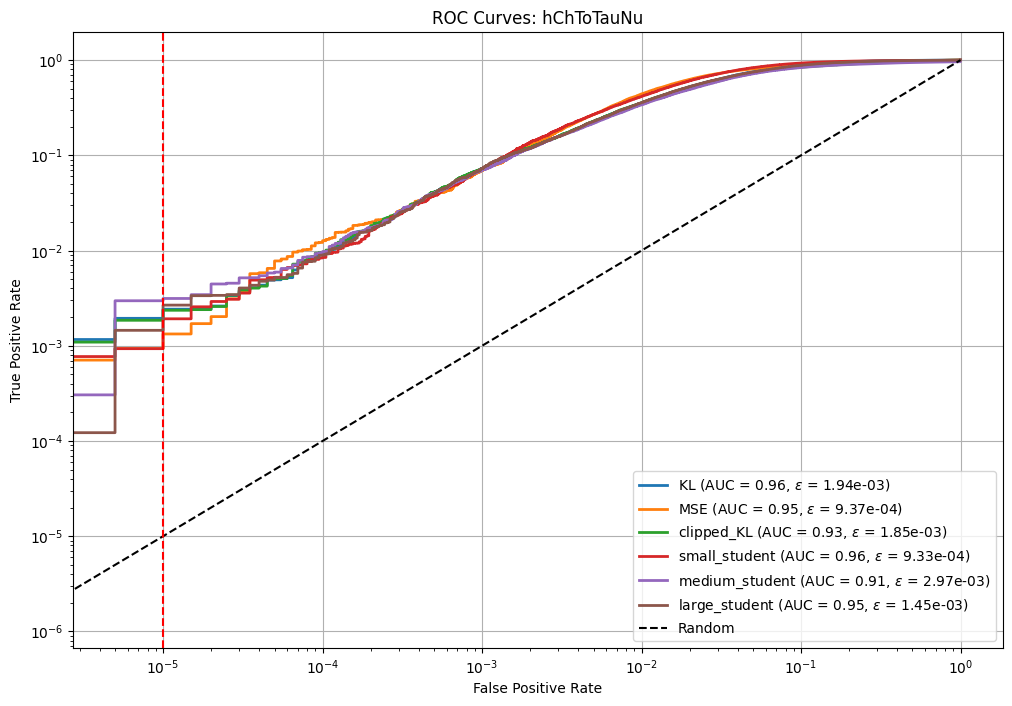

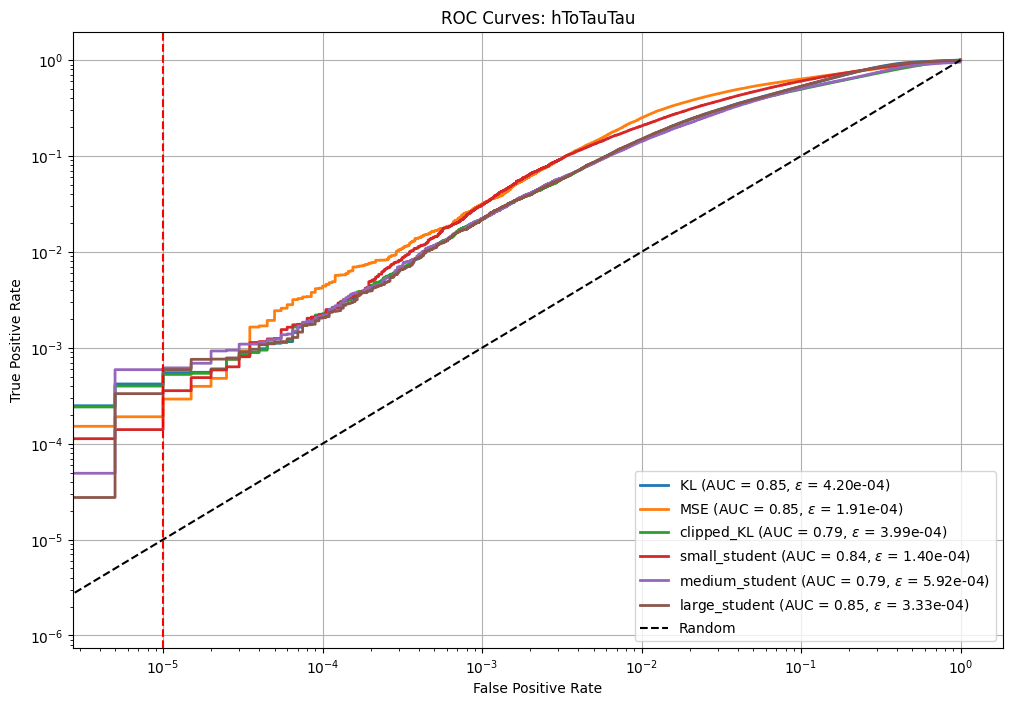

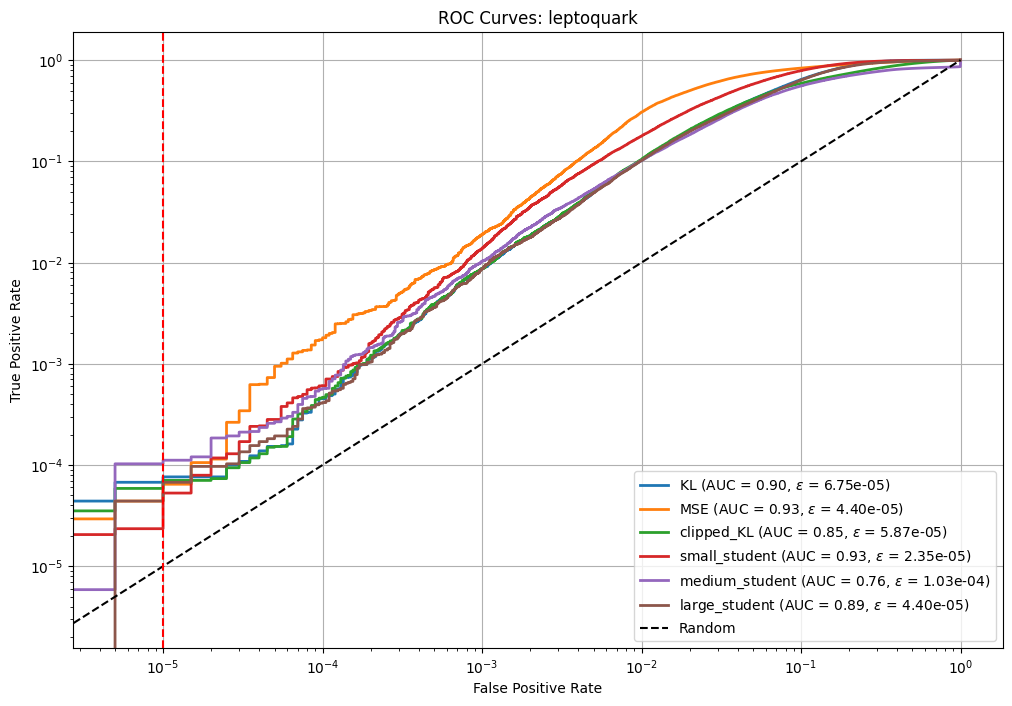

In [ ]:
skip_tags = ['Background', 'train', 'val']
AD_score_types = ['KL', 'MSE', 'clipped_KL', 'small_student', 'medium_student', 'large_student']

bkg_scores = {
        score_type: datasets['Background'][f'{score_type}_AD_scores']
        for score_type in AD_score_types
    }

for tag, data_dict in datasets.items():
    if tag in skip_tags: continue
    plt.figure(figsize=(12, 8))

    signal_scores = {
        score_type: data_dict[f'{score_type}_AD_scores']
        for score_type in AD_score_types
    }

    combined_scores = {
        score_type: np.concatenate([bkg_scores[score_type], signal_scores[score_type]])
        for score_type in AD_score_types
    }

    combined_labels = np.concatenate([np.zeros_like(bkg_scores['KL']), np.ones_like(signal_scores['KL'])])

    for score_type, scores in combined_scores.items():
        FPRs, TPRs, thresholds = roc_curve(combined_labels, scores)
        roc_auc = auc(FPRs, TPRs)
        threshold_idx = np.argmin(np.abs(FPRs - 1e-5))
        threshold_tpr = TPRs[threshold_idx]

        plt.plot(FPRs, TPRs, label=f'{score_type} (AUC = {roc_auc:.2f}, $\epsilon$ = {threshold_tpr:.2e})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.axvline(x=1e-5, color='red', linestyle='--')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves: {tag}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

In [ ]:
def save_subdicts_to_h5(main_dict, save_dir):
    """
    Saves each sub-dictionary of NumPy arrays in the main_dict to separate HDF5 files.

    Args:
        main_dict (dict): A dictionary of dictionaries where the innermost values are NumPy arrays.
        save_dir (str): The directory where the HDF5 files will be saved.
    """
    # Ensure the save directory exists
    os.makedirs(save_dir, exist_ok=True)

    for sub_dict_name, sub_dict in main_dict.items():
        file_path = os.path.join(save_dir, f"{sub_dict_name}.h5")
        with h5py.File(file_path, 'w') as f:
            for key, arr in sub_dict.items():
                f.create_dataset(key, data=arr)
        print(f"Saved {sub_dict_name} to {file_path}")

In [ ]:
save_subdicts_to_h5(datasets, './saved_datasets')

Saved Ato4l to ./saved_datasets/Ato4l.h5
Saved Background to ./saved_datasets/Background.h5
Saved hChToTauNu to ./saved_datasets/hChToTauNu.h5
Saved hToTauTau to ./saved_datasets/hToTauTau.h5
Saved leptoquark to ./saved_datasets/leptoquark.h5
Saved train to ./saved_datasets/train.h5
Saved val to ./saved_datasets/val.h5


### Now run some checks for the students

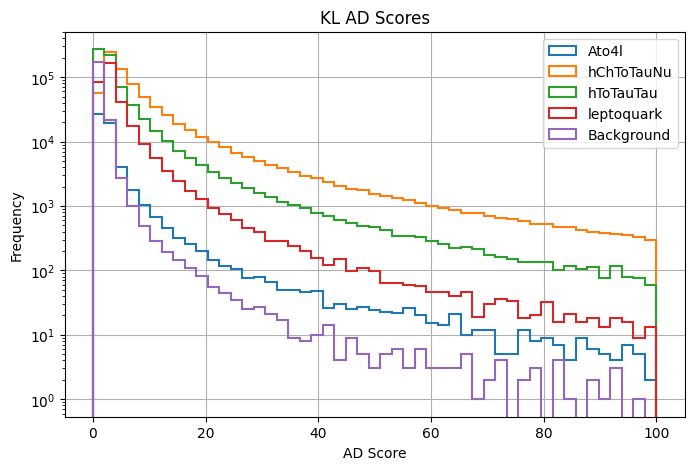

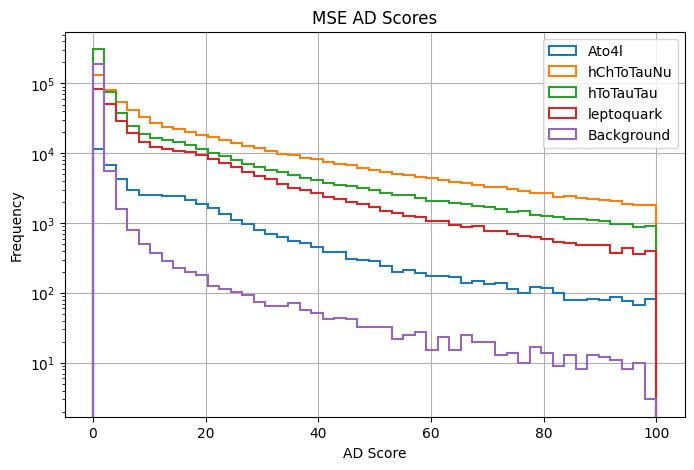

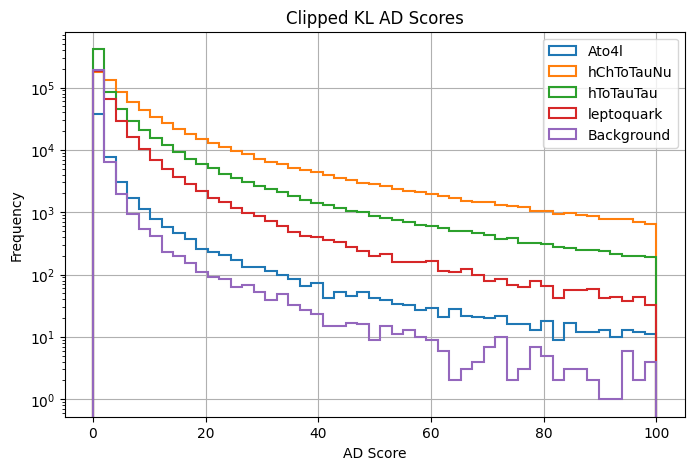

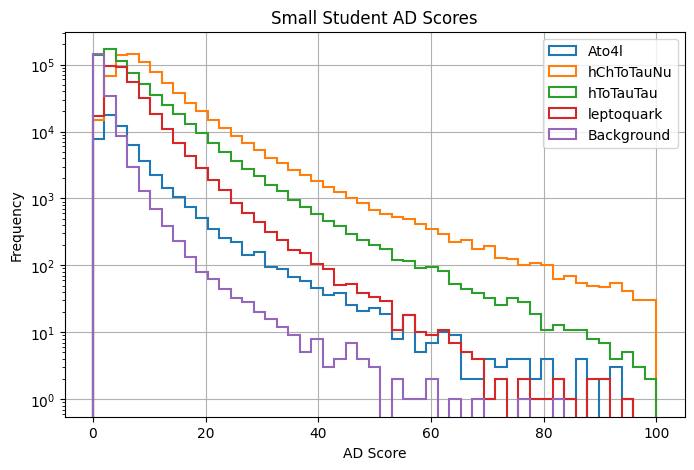

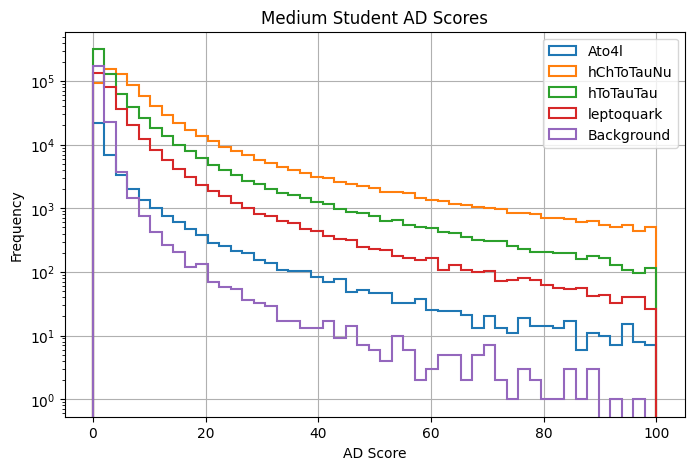

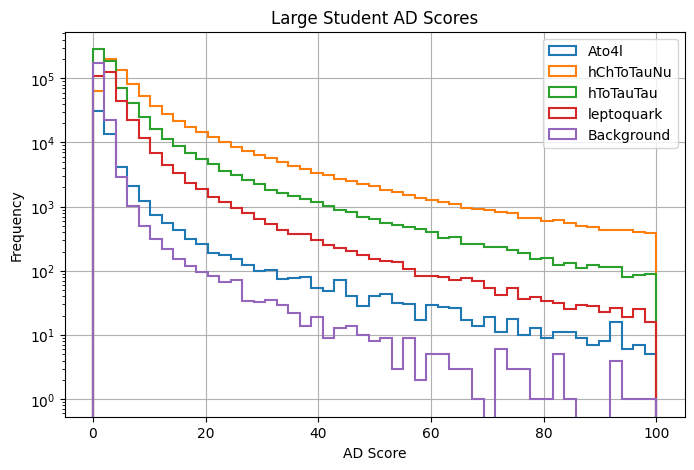

In [ ]:
score_types = [
    ("KL_AD_scores", "KL AD Scores"),
    ("MSE_AD_scores", "MSE AD Scores"),
    ("clipped_KL_AD_scores", "Clipped KL AD Scores"),
    ("small_student_AD_scores", "Small Student AD Scores"),
    ("medium_student_AD_scores", "Medium Student AD Scores"),
    ("large_student_AD_scores", "Large Student AD Scores"),
]

for score_key, nice_title in score_types:
    plt.figure(figsize=(8, 5))

    skip_tags = ['train', 'val']
    bins = np.linspace(0, 100, 50)
    for tag, data_dict in datasets.items():
        if tag in skip_tags: continue

        plt.hist(
            data_dict[score_key],
            histtype='step',
            linewidth=1.5,
            label=tag,
            bins=bins
        )

    plt.legend()
    plt.xlabel('AD Score')
    plt.ylabel('Frequency')
    plt.yscale('log')
    plt.title(nice_title)
    plt.grid(True)
    plt.show()

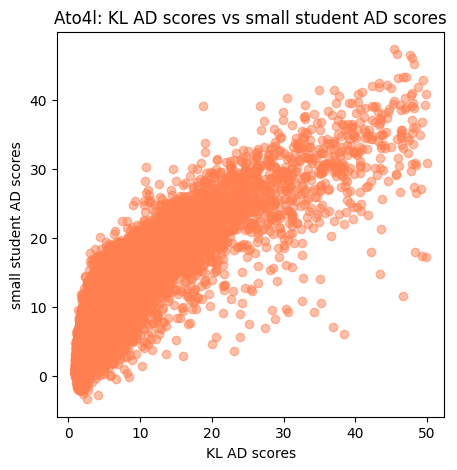

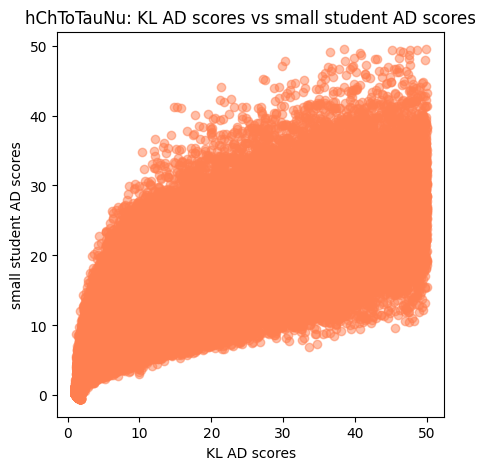

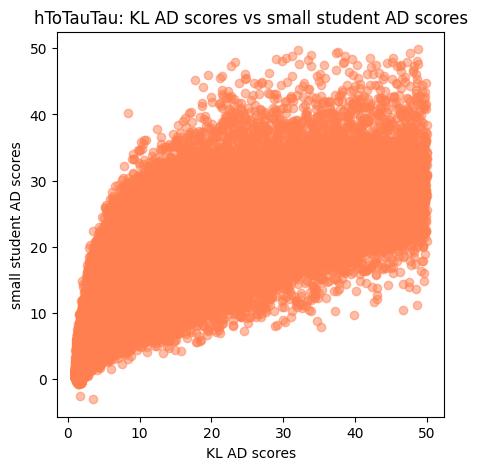

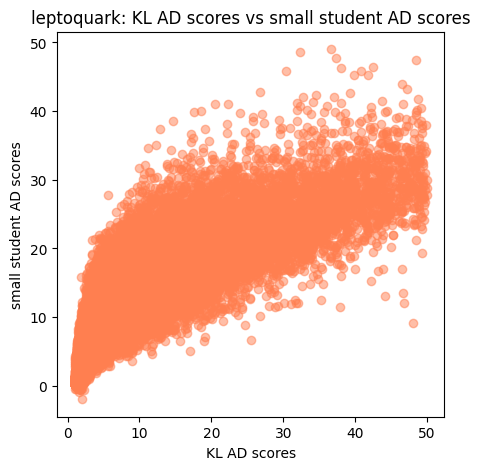

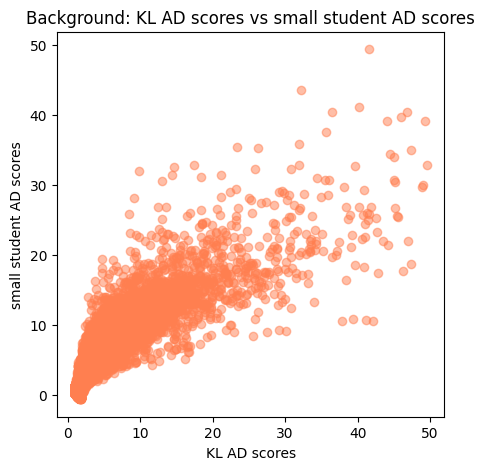

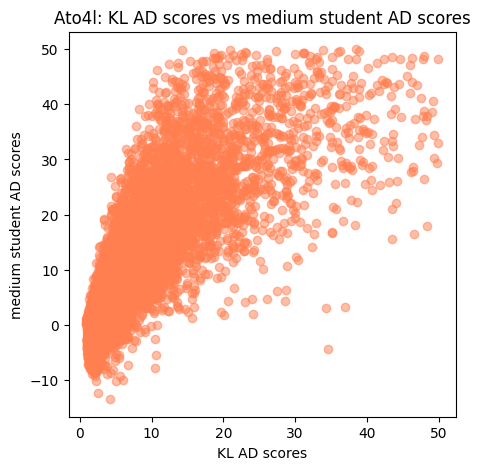

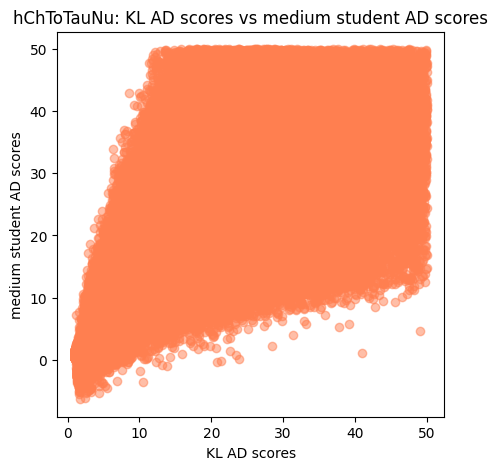

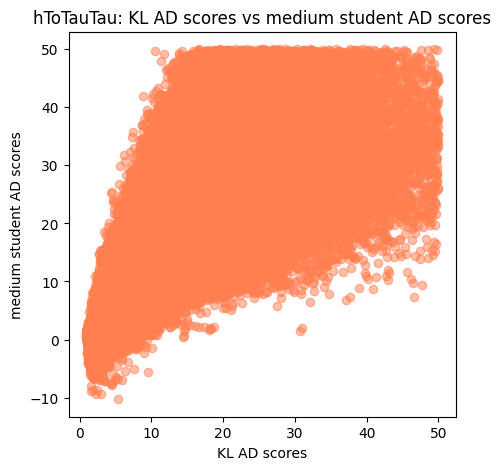

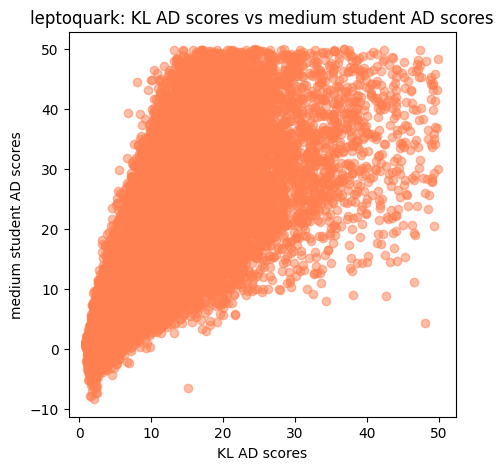

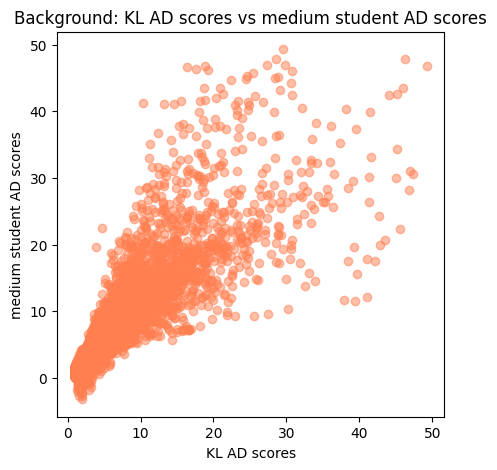

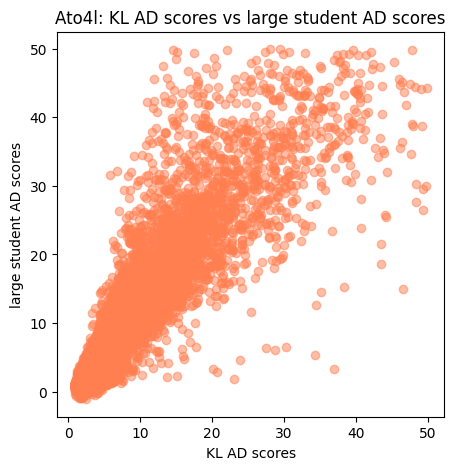

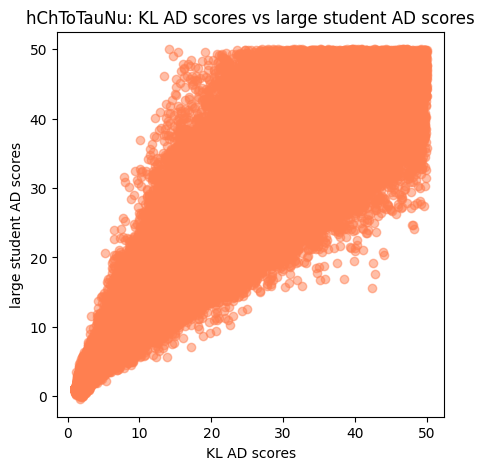

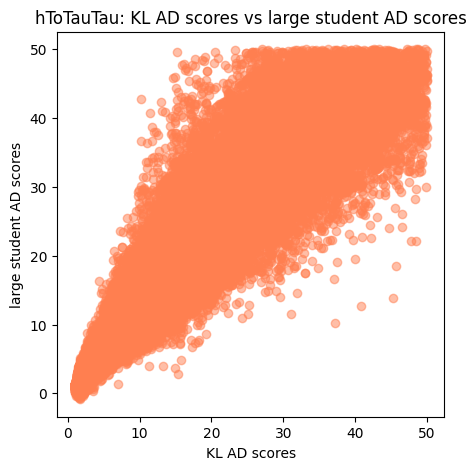

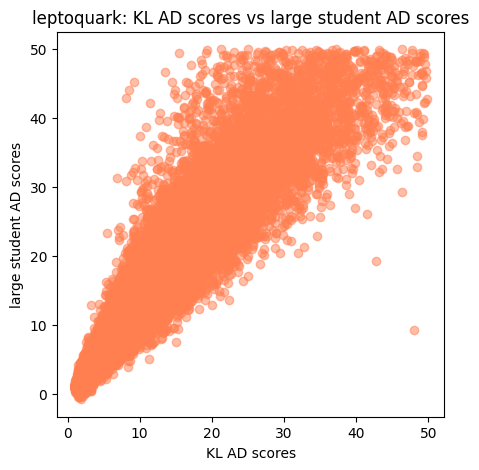

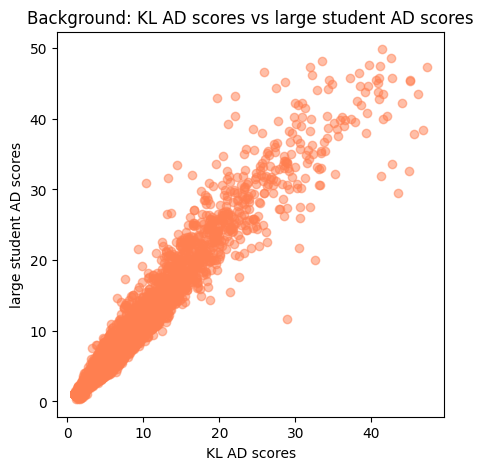

In [ ]:
skip_tags = ['train', 'val']
for size in ['small', 'medium', 'large']:

    for tag, data_dict in datasets.items():
        if tag in skip_tags: continue

        plt.figure(figsize=(5, 5))
        mask = (data_dict['KL_AD_scores'] < 50) & (data_dict[f'{size}_student_AD_scores'] < 50)
        plt.scatter(
            data_dict['KL_AD_scores'][mask],
            data_dict[f'{size}_student_AD_scores'][mask],
            alpha=0.5,
            color='coral'
        )
        plt.title(tag + ': KL AD scores vs ' + size + ' student AD scores')
        plt.xlabel('KL AD scores')
        plt.ylabel(size + ' student AD scores')
        plt.show()


In [ ]:
# I just realized that I only saved the background_test dataset, not the background_train or background_vals.
# So I'll have to go back to the other notebook, rerun that, and also save those datasets and AD scores, and then edit this again